# Lesson 08 — Maximum Likelihood Estimation

<h2 dir="rtl">פרק 1 — איך statsmodels הגיע ל-23.22?</h2>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

<h2 dir="rtl">פרק 2 — המטבע: הניחוש הטבעי הוא MLE</h2>

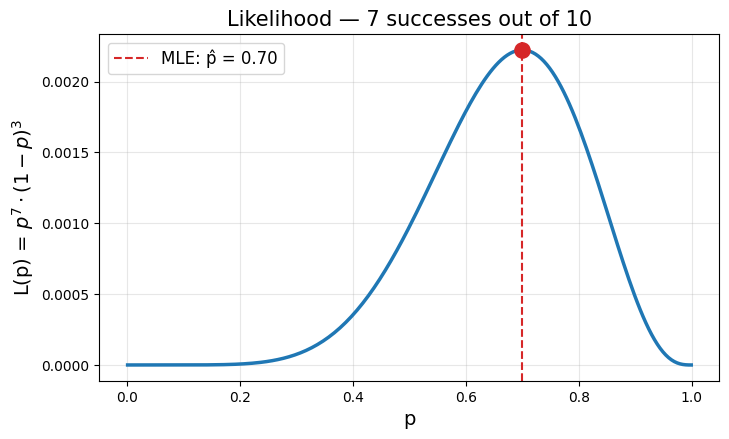

L(0.5) = 0.00098
L(0.7) = 0.00222  ← MLE
L(0.9) = 0.00048
L(0.7) / L(0.5) = 2.28


In [13]:
n_succ, n_fail = 7, 3
p_grid = np.linspace(0.001, 0.999, 200)
L = (p_grid ** n_succ) * ((1 - p_grid) ** n_fail)

p_hat_mle = n_succ / (n_succ + n_fail)
L_at_mle = (p_hat_mle ** n_succ) * ((1 - p_hat_mle) ** n_fail)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(p_grid, L, color='tab:blue', linewidth=2.5)
ax.axvline(p_hat_mle, color='tab:red', linestyle='--', label=f'MLE: p̂ = {p_hat_mle:.2f}')
ax.scatter([p_hat_mle], [L_at_mle], color='tab:red', s=120, zorder=5)
ax.set_xlabel('p', fontsize=14)
ax.set_ylabel(r'L(p) = $p^7 \cdot (1-p)^3$', fontsize=14)
ax.set_title('Likelihood — 7 successes out of 10', fontsize=15)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.show()

print(f'L(0.5) = {(0.5**7)*(0.5**3):.5f}')
print(f'L(0.7) = {(0.7**7)*(0.3**3):.5f}  ← MLE')
print(f'L(0.9) = {(0.9**7)*(0.1**3):.5f}')
print(f'L(0.7) / L(0.5) = {((0.7**7)*(0.3**3)) / ((0.5**7)*(0.5**3)):.2f}')

<h2 dir="rtl">פרק 3 — אותו רעיון על Challenger</h2>

In [14]:
data = pd.read_csv('oring.csv')
data['failure'] = (data['num_failure'] >= 1).astype(int)
X = data['temp'].values
y = data['failure'].values

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_likelihood(beta0, beta1, X, y):
    p = sigmoid(beta0 + beta1 * X)
    eps = 1e-15
    return np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

print(f'{"β₀":>10}{"β₁":>10}{"log L":>12}')
print('-' * 32)
for b0, b1 in [(0, 0), (10, -0.15), (20, -0.30), (23.22, -0.358), (30, -0.45)]:
    ll = log_likelihood(b0, b1, X, y)
    marker = '  ← best!' if abs(b0 - 23.22) < 0.01 else ''
    print(f'{b0:>10.2f}{b1:>+10.3f}{ll:>+12.3f}{marker}')

        β₀        β₁       log L
--------------------------------
      0.00    +0.000     -15.942
     10.00    -0.150      -9.526
     20.00    -0.300      -7.704
     23.22    -0.358      -7.072  ← best!
     30.00    -0.450      -7.503


<h2 dir="rtl">פרק 4 — קווי likelihood: איך נראית התאמה טובה</h2>

In [17]:
def plot_likelihood_lines(ax, beta0, beta1, X, y, title):
    x_grid = np.linspace(30, 90, 200)
    p_curve = sigmoid(beta0 + beta1 * x_grid)
    ax.plot(x_grid, p_curve, color='tab:green', linewidth=2.5)
    ax.scatter(X[y == 1], y[y == 1], color='tab:blue', s=80, zorder=5, label='failure (y=1)')
    ax.scatter(X[y == 0], y[y == 0], color='tab:red', s=80, zorder=5, label='no failure (y=0)')
    for xi, yi in zip(X, y):
        pi = sigmoid(beta0 + beta1 * xi)
        ax.plot([xi, xi], [yi, pi], color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ll = log_likelihood(beta0, beta1, X, y)
    ax.set_title(f'{title}\nlog L = {ll:.2f}', fontsize=13)
    ax.set_xlabel('Temperature (F)', fontsize=11)
    ax.set_ylabel('P(failure)', fontsize=11)
    ax.grid(alpha=0.3)

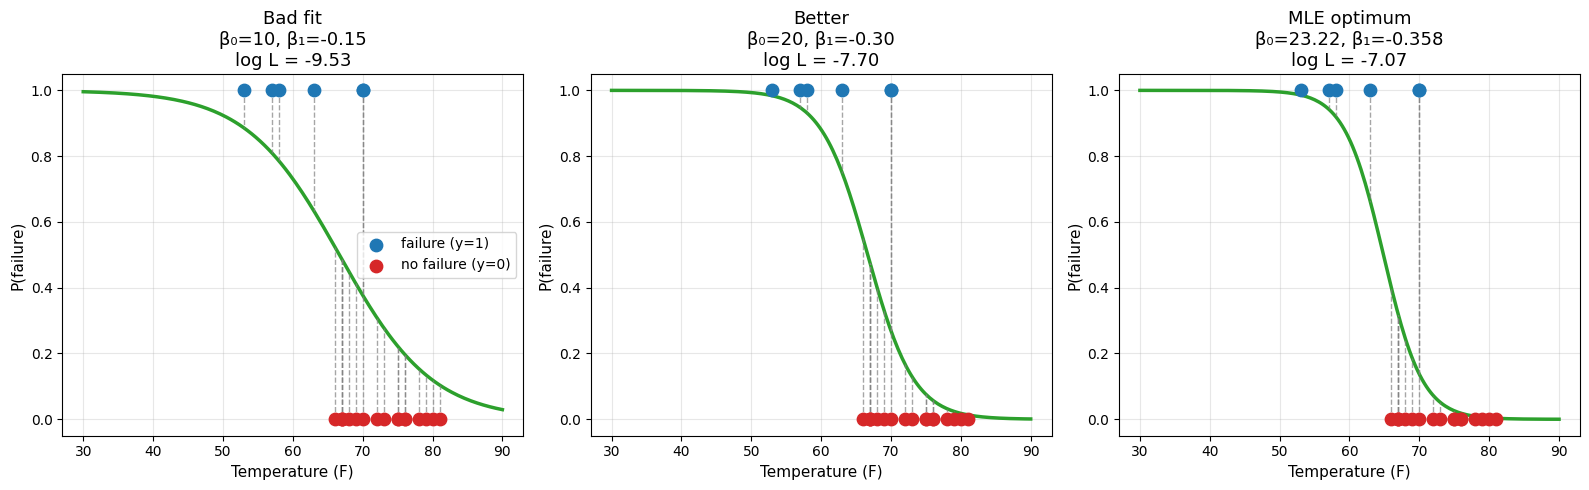

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_likelihood_lines(axes[0], 10, -0.15, X, y, title='Bad fit\nβ₀=10, β₁=-0.15')
plot_likelihood_lines(axes[1], 20, -0.30, X, y, title='Better\nβ₀=20, β₁=-0.30')
plot_likelihood_lines(axes[2], 23.22, -0.358, X, y, title='MLE optimum\nβ₀=23.22, β₁=-0.358')
axes[0].legend(fontsize=10, loc='center right')
plt.tight_layout()
plt.show()

<h2 dir="rtl">פרק 5 — תוכנה מטפסת על הר</h2>

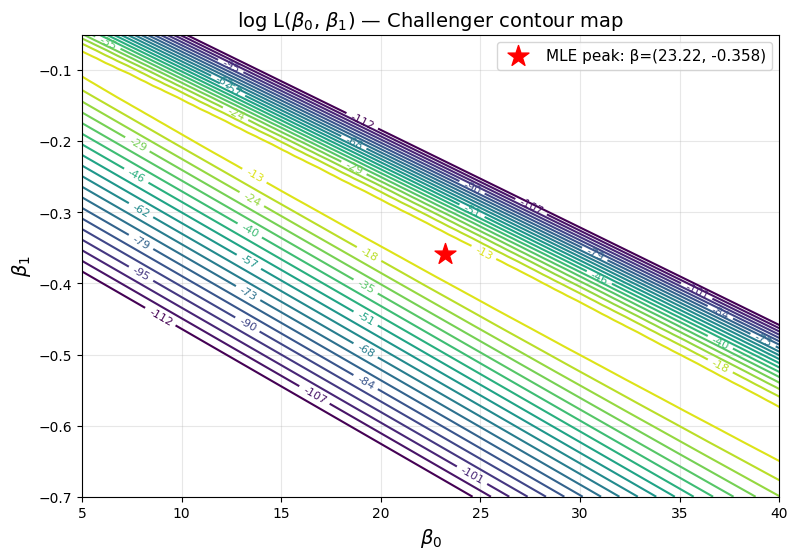

sm.Logit result:  β₀ = 23.2216, β₁ = -0.3576
  log-Likelihood = -7.0714


In [24]:
b0_grid = np.linspace(5, 40, 60)
b1_grid = np.linspace(-0.7, -0.05, 60)
B0, B1 = np.meshgrid(b0_grid, b1_grid)
LL = np.zeros_like(B0)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        LL[i, j] = log_likelihood(B0[i, j], B1[i, j], X, y)

fig, ax = plt.subplots(figsize=(9, 6))
levels = np.linspace(LL.max() - 105, LL.max(), 20) #
cs = ax.contour(B0, B1, LL, levels=levels, cmap='viridis')
ax.clabel(cs, inline=True, fontsize=8, fmt='%.0f')
ax.scatter([23.22], [-0.358], s=250, color='red', marker='*', zorder=5,
           label='MLE peak: β=(23.22, -0.358)')
ax.set_xlabel(r'$\beta_0$', fontsize=14)
ax.set_ylabel(r'$\beta_1$', fontsize=14)
ax.set_title(r'log L($\beta_0$, $\beta_1$) — Challenger contour map', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)
plt.show()

# Confirmation: sm.Logit lands exactly on the peak
data['intercept'] = 1
m = sm.Logit(data['failure'], data[['intercept', 'temp']]).fit(disp=0)
print(f'sm.Logit result:  β₀ = {m.params["intercept"]:.4f}, β₁ = {m.params["temp"]:.4f}')
print(f'  log-Likelihood = {m.llf:.4f}')

<h2 dir="rtl">פרק 6 — סיכום + הצצה לשיעור 09</h2>

### Write your answer here.

<div dir="rtl">

תרגיל אופציונלי לבית: על דאטה Challenger, חשב את $\log L$ בנקודה $(\beta_0, \beta_1) = (15, -0.20)$. מה הערך? **קרוב לפסגה ($-7.07$) או רחוק ממנה?**

</div>